In [5]:
import spatialdata as sd
import spatialdata_io
import sopa

import troutpy

In [19]:
samples = {'inactive_0': 
 '/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_CML]MS_spinal_cord_Xenium_human_brain_panel/xenium_datasets-1/output-XETG00045__0003524__active__20230510__111824-20230725T092912Z-001/output-XETG00045__0003524__active__20230510__111824',
'inactive_1': 
 '/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_CML]MS_spinal_cord_Xenium_human_brain_panel/xenium_datasets-1/output-XETG00045__0003385__inactive__20230510__111824-20230725T094731Z-001/output-XETG00045__0003385__inactive__20230510__111824',
'active_0': 
 '/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_CML]MS_spinal_cord_Xenium_human_brain_panel/20230829__105411__20230829_Goncalo_Petra_run2/output-XETG00047__0010759__MS-C_2012-078__20230829__105447',
'active_1': 
 '/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_CML]MS_spinal_cord_Xenium_human_brain_panel/20230829__105411__20230829_Goncalo_Petra_run2/output-XETG00047__0010771__MS-C_2017-100__20230829__105447',
'control_0': 
 '/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_CML]MS_spinal_cord_Xenium_human_brain_panel/20230824__123243__20230824_GONCALO_PETRA_run3/output-XETG00047__0010869__Ctrl-C_2012-071__20230824__123323',
'control_1': 
 '/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_CML]MS_spinal_cord_Xenium_human_brain_panel/20230824__123243__20230824_GONCALO_PETRA_run3/output-XETG00047__0010872__Ctrl-C_2017-16__20230824__123323',
}


In [20]:
import spatialdata_io

sdata_dict = {}

for sample_id, path in samples.items():
    print(f"📦 Loading {sample_id}")
    sdata_dict[sample_id] = spatialdata_io.xenium(path)

📦 Loading inactive_0
📦 Loading inactive_1
📦 Loading active_0
📦 Loading active_1
📦 Loading control_0
📦 Loading control_1


In [32]:
adata_list = []
for sample in sdata_dict.keys():
    print(sample)
    adata_int = sdata_dict[sample].tables['table']
    adata_int.obs['sample_id'] = sample
    adata_list.append(adata_int)

inactive_0
inactive_1
active_0
active_1
control_0
control_1


In [33]:
adata_list

[AnnData object with n_obs × n_vars = 136079 × 266
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'sample_id'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 107147 × 266
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'sample_id'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatialdata_attrs'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 157344 × 266
     obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'sample_id'
  

In [35]:
import scanpy as sc

In [36]:
adata_all = sc.concat(adata_list, join='outer')

In [37]:
adata_all.obs_names_make_unique()

In [40]:
adata_all.write('../data/hm_xenium_ms_raw_unfilt.h5ad')

In [51]:
adata_all.X

np.float64(10.0)

In [41]:

# Number of genes per cell
adata_all.obs["n_genes"] = (adata_all.X > 0).sum(axis=1).A1

# Number of UMIs per cell (if counts are in X)
adata_all.obs["n_counts"] = adata_all.X.sum(axis=1).A1


In [42]:
min_genes = 10
min_counts = 30
max_genes = 4000

adata_all = adata_all[
    (adata_all.obs["n_genes"] > min_genes) &
    (adata_all.obs["n_counts"] > min_counts) &
    (adata_all.obs["n_genes"] < max_genes)
].copy()

In [43]:
len(adata_all)

626107

In [44]:
adata_all.write('../data/hm_xenium_ms_raw_filt.h5ad')

In [45]:
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)
sc.pp.scale(adata_all, max_value=10)

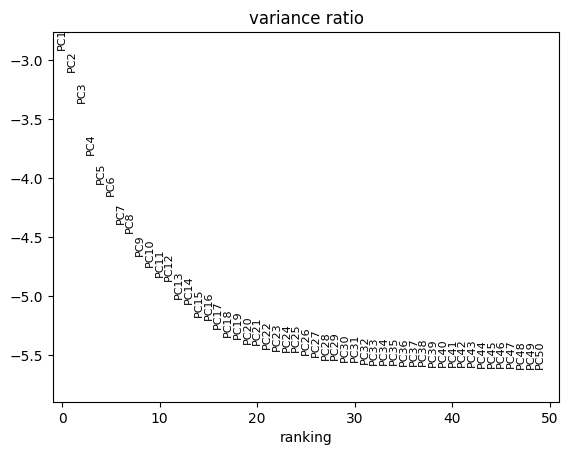

In [46]:
import matplotlib.pyplot as plt
plt.rcdefaults()
sc.tl.pca(adata_all)
sc.pl.pca_variance_ratio(adata_all, n_pcs=50, log=True)
sc.pp.neighbors(adata_all, n_neighbors=30, n_pcs=40, metric="cosine")

In [47]:
sc.tl.umap(
    adata_all,
    min_dist=0.05,
    spread=1.5,
    negative_sample_rate=20,
)

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


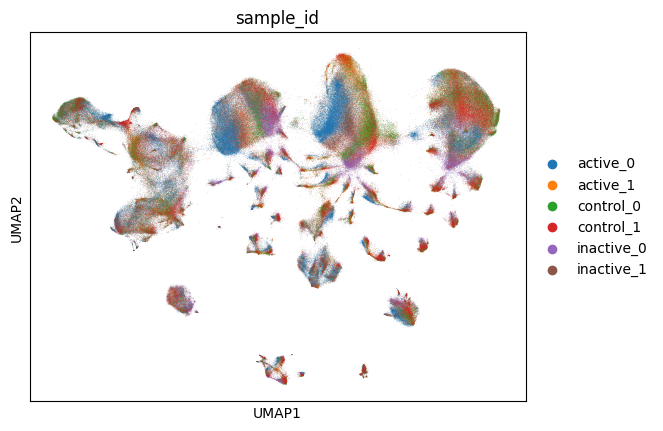

In [48]:
sc.pl.umap(adata_all, color = ['sample_id'])

In [49]:
resolutions = [0.5, 1,1.5, 2,2.5,3,3.5]

for resolution in resolutions:
    key = f'leiden_{resolution}'

    if key in adata_all.obs.columns:
        print(f"Skipping {resolution}: {key} already exists.")
    else:
        print(f"Clustering at resolution {resolution}...")
        sc.tl.leiden(adata_all, resolution=resolution, key_added=key)
        print("Done.")

    # plot UMAP
    sc.pl.umap(adata_all, color=key, legend_loc='on data', frameon=False)

Clustering at resolution 0.5...


ImportError: Please install the leiden algorithm: `conda install -c conda-forge leidenalg` or `pip3 install leidenalg`.